# 0. Setup

In [68]:
# Librerías
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# Configuración para ver más filas y columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# Deshabilitar notación científica
pd.options.display.float_format = '{:.2f}'.format

# 1. Entendimiento inicial de datos

In [69]:
# Cargar datos
df = pq.read_table("data/secop_bienes.parquet").to_pandas()

In [70]:
# Explorar datos
df.head(n=15)

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.00,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.00,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.00,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,V1.41115300,ADQUISICIÓN DE UN SISTEMA DE SONAR 3D DE ALTA ...,2019-07-25,2019-07-12,2019-11-30,Dia(s),Como acordado previamente,CASCO ANTIGUO,76044753,No,No,Otro,CO,733992000.00,0,0,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.92121701,Suministro de equipos para la instalación de t...,2019-11-01,2019-06-17,2019-12-30,No definido,No Definido,hr technology sas,900815825,Si,No,No Definido,CO,6000000.00,0,0,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...
5,CO1.PCCNTR.1000912,CÁRCEL Y PENITENCIARIA DE MEDIA SEGURIDAD DE N...,Huila,Rivera,Nacional,Ley de Justicia,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.44122003,ADQUISICIÓN DE MATERIALES DE OFICINA Y ELEMENT...,2019-06-19,2019-06-18,2019-08-30,No definido,Como acordado previamente,PAPELERIA EL DESCUENTO DE NEIVA,36183257,Si,No,Mujer,CO,16496353.00,16496353,16496353,0,0,No Definido,No,Distribuido,Funcionamiento,Cerrado,No,No,{'url': 'https://community.secop.gov.co/Public...
6,CO1.PCCNTR.1000913,INVIAS,Distrito Capital de Bogotá,Bogotá,Nacional,Transporte,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.72141000,SUMINISTRO DE MEZCLA ASFÁLTICA VÍA 6006; MÍNIM...,2019-07-11,2019-07-05,2019-07-20,Dia(s),No Definido,Proyectos de Ingeniería Cumbre S.A.S.,900868183,Si,No,Hombre,CO,72159089.00,0,0,72159089,0,No Definido,No,Distribuido

In [71]:
# Dimensiones (filas, columnas)
df.shape

(196391, 36)

In [72]:
# Información de los datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  str           
 1   nombre_entidad                    196391 non-null  str           
 2   departamento                      196391 non-null  str           
 3   ciudad                            196391 non-null  str           
 4   orden                             196391 non-null  str           
 5   sector                            196391 non-null  str           
 6   rama                              196391 non-null  str           
 7   entidad_centralizada              196391 non-null  str           
 8   tipo_de_contrato                  196391 non-null  str           
 9   modalidad_de_contratacion         196391 non-null  str           
 10  codigo_de_categoria_principal     196391 no

In [73]:
# Estadísticas descriptivas
df.describe()

,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados
count,196391,193951,196391,196391.00,196391.00,196391.00,196391.00,196391.00
mean,2023-02-27 22:45:53.539622,2023-03-01 13:02:29.326376,2023-06-11 04:37:50.596921,65824255027.86,119491099.77,148409156.65,65704762982.84,5.11
min,2019-01-01 00:00:00,2016-06-27 00:00:00,0202-12-31 00:00:00,0.00,0.00,0.00,-84184884.00,0.00
25%,2021-09-10 00:00:00,2021-09-17 00:00:00,2021-12-20 00:00:00,12021214.00,0.00,0.00,0.00,0.00
50%,2023-05-30 00:00:00,2023-06-05 00:00:00,2023-10-27 00:00:00,33600000.00,0.00,3207328.00,6717571.00,0.00
75%,2024-11-07 00:00:00,2024-11-14 00:00:00,2024-12-31 00:00:00,100000000.00,28120772.50,37086225.00,42411892.00,0.00
max,2025-12-31 00:00:00,2026-12-16 00:00:00,2065-01-31 00:00:00,12858450316000000.00,594403394800.00,594503164818.00,12858450316000000.00,14276.00
std,NaN,NaN,NaN,29015352967837.05,2444116099.87,2969809583.32,29015353088019.10,40.66


# 1.1. Atributos que consideramos más importantes

## 1.1.1. Atributos objetivo

El objetivo de negocio es identificar patrones, tendencias y oportunidades que se puedan correlacionar con desviaciones del plan inicial de la ejecución de un contrato.

Decidimos agrupar por senales los atributos, según:
- Desviación de tiempo
- Desviación de recursos
- Desviación de cierre

### 1.1.1.1. Desviación de tiempo
Atributo: `dias_adicionados`

Se realizará un análisis univariado de esta variable **numérica** (conteo de días adicionados al plazo).


In [74]:
print(df['dias_adicionados'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['dias_adicionados'].skew())
print("Kurtosis:", df['dias_adicionados'].kurtosis())

count   196391.00
mean         5.11
std         40.66
min          0.00
1%           0.00
5%           0.00
25%          0.00
50%          0.00
75%          0.00
95%         30.00
99%        122.00
99.9%      316.00
max      14276.00
Name: dias_adicionados, dtype: float64
Sesgo: 222.19171449720685
Kurtosis: 77269.88230930727


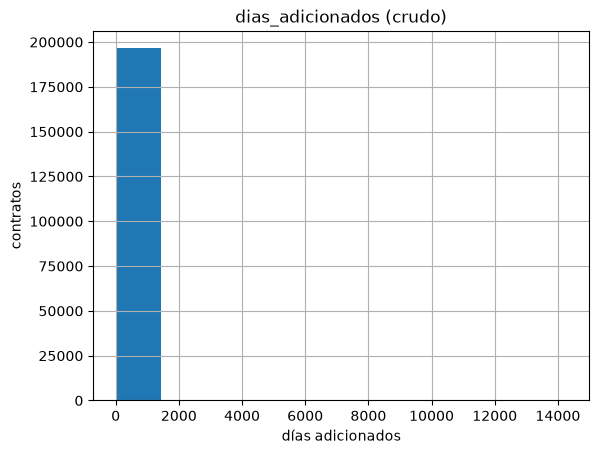

In [75]:
df['dias_adicionados'].hist()
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('dias_adicionados (crudo)')
plt.show()

`dias_adicionados` es una variable **cero-inflada**, con cola derecha y un outlier extremo. Pandas reporta **kurtosis excesiva** (una normal vale 0, no 3).

- Sesgo 222 y kurtosis 77,270: masa a la izquierda y colas mucho más pesadas que una normal.
- Mediana, p25 y p75 en 0: la mayoría de contratos no se prorrogan (~90.5%).
- Media 5.11 arrastrada por la cola; no describe al contrato típico.
- p99 = 122 días vs máximo = 14,276 días (~39 años): se va a excluir este dato, *suponiendo* una validación con un experto de negocio. 

In [76]:
df['dias_adicionados_v2'] = df['dias_adicionados'].where(
    df['dias_adicionados'] != df['dias_adicionados'].max()
)

print("Nulos en dias_adicionados_v2:", df['dias_adicionados_v2'].isna().sum())
print("Máximo original:", df['dias_adicionados'].max())
print("Máximo v2:", df['dias_adicionados_v2'].max())
print(df['dias_adicionados_v2'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['dias_adicionados_v2'].skew())
print("Kurtosis:", df['dias_adicionados_v2'].kurtosis())

Nulos en dias_adicionados_v2: 1
Máximo original: 14276
Máximo v2: 874.0
count   196390.00
mean         5.03
std         24.83
min          0.00
1%           0.00
5%           0.00
25%          0.00
50%          0.00
75%          0.00
95%         30.00
99%        122.00
99.9%      315.61
max        874.00
Name: dias_adicionados_v2, dtype: float64
Sesgo: 9.111907156819608
Kurtosis: 127.40991670265376


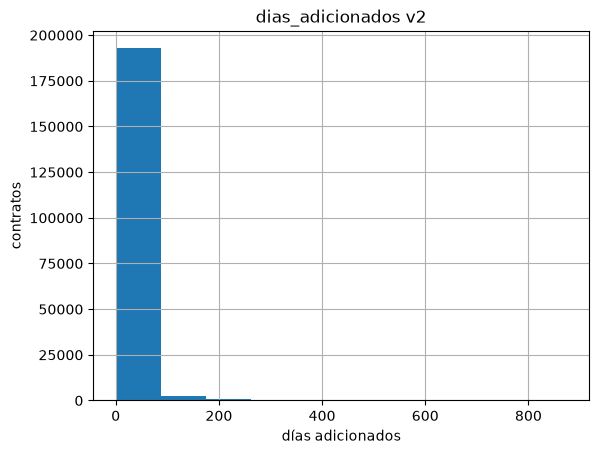

In [77]:
df['dias_adicionados_v2'].hist()
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('dias_adicionados v2')
plt.show()


También se hizo un análisis de sólo contratos prorrogados, para entender mejor el problema.

count   18670.00
mean       52.96
std        62.82
min         1.00
1%          2.00
5%          5.00
25%        15.00
50%        31.00
75%        62.00
95%       181.00
99%       322.00
99.9%     482.66
max       874.00
Name: dias_adicionados_v2, dtype: float64
Sesgo: 3.1902195298581604
Kurtosis: 16.914264813891865


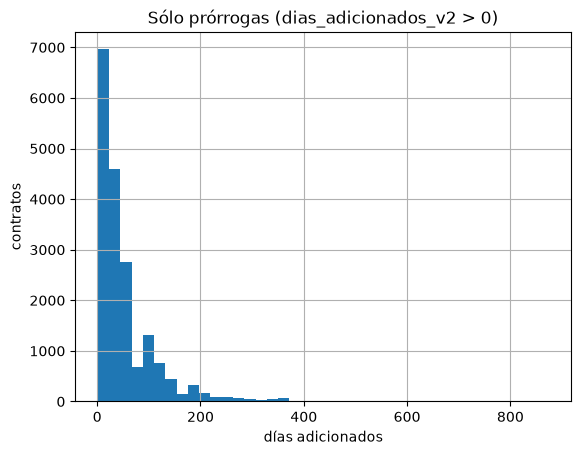

In [78]:
prorrogas = df.loc[df['dias_adicionados_v2'] > 0, 'dias_adicionados_v2']

print(prorrogas.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", prorrogas.skew())
print("Kurtosis:", prorrogas.kurtosis())

prorrogas.hist(bins=40)
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('Sólo prórrogas (dias_adicionados_v2 > 0)')
plt.show()

Conclusión: la prórroga es **poco frecuente**, y cuando ocurre suele ser corta.

- Solo **18,671 contratos (9.5%)** tienen `dias_adicionados > 0`. El resto no se desvía en plazo.
- Entre los prorrogados (sin el 14,276): mediana **31 días**, media **53**, p75 **62**. Casi la mitad se extiende a lo sumo un mes; ~83% a lo sumo 90 días.
- Sigue habiendo cola derecha (sesgo ~3.2): p95 = 181 días y 77 contratos superan un año (máximo 874). Son pocos, pero son los de mayor riesgo operativo.
- Para focalizar supervisión, el indicador útil en firma no es el promedio de días (no representa al típico), sino **si el contrato se prorroga** y, en segunda instancia, las prórrogas largas (>90 o >180 días).
 

## 1.1.1.2 Desviación de recursos

Atributo 1: `valor_del_contrato`

Atributo 2: `valor_pagado`

Análisis univariado de variables **numéricas** (pesos). En `valor_del_contrato` se anulan los ceros: un contrato de compraventa/suministro por 0 COP no tiene sentido. En `valor_pagado` los ceros **sí se conservan**: son la señal de presupuesto no ejecutado.


count              196391.00
mean          65824255027.86
std        29015352967837.05
min                     0.00
1%                 701068.00
5%                2309772.50
25%              12021214.00
50%              33600000.00
75%             100000000.00
95%             800000000.00
99%            4118481942.98
99.9%         30959141166.37
max     12858450316000000.00
Name: valor_del_contrato, dtype: float64
Sesgo: 443.16015148594323
Kurtosis: 196390.94657048953


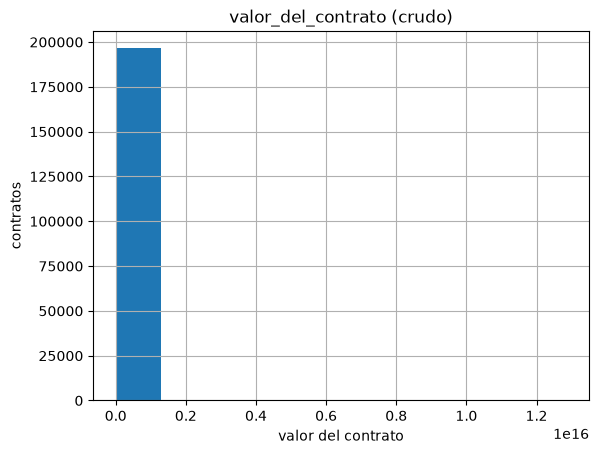

In [79]:
print(df['valor_del_contrato'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_del_contrato'].skew())
print("Kurtosis:", df['valor_del_contrato'].kurtosis())

df['valor_del_contrato'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title('valor_del_contrato (crudo)')
plt.show()

El histograma crudo no se lee: un solo contrato vale **12,858,450,316,000,000** COP (compra de tres bienes), ~400,000 veces el p99.9. Sesgo 443 y kurtosis 196,391. Mediana 33.6 millones vs media 65,824 millones. También hay **188 ceros**, que no corresponden a un contrato de bienes. 

En `valor_del_contrato_v2` se anula el máximo y los ceros, sin borrar las filas. Vamos a suponer que esta decisión también se validó con un experto del negocio.

Ceros originales en valor_del_contrato: 188
Nulos en valor_del_contrato_v2: 189
Máximo original: 1.2858450316e+16
Máximo v2: 2846224257835.0
Mínimo v2: 0.01
count          196202.00
mean        350867744.35
std       10706517268.26
min                 0.01
1%             756845.10
5%            2354620.00
25%          12085031.50
50%          33681770.00
75%         100000000.00
95%         800000000.00
99%        4119983132.70
99.9%     30817943546.68
max     2846224257835.00
Name: valor_del_contrato_v2, dtype: float64
Sesgo: 200.00553393198126
Kurtosis: 46306.79031015586


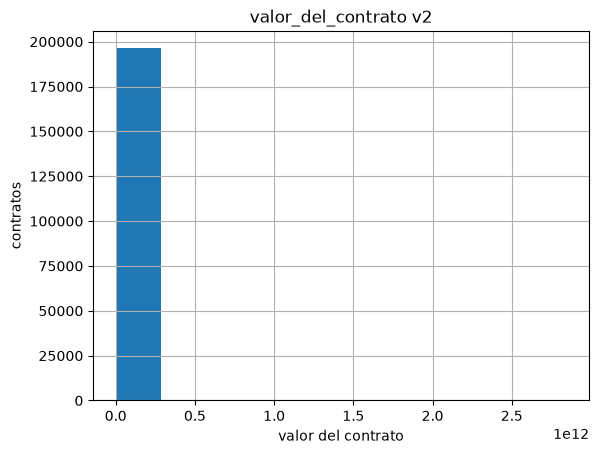

In [80]:
df['valor_del_contrato_v2'] = df['valor_del_contrato'].where(
    (df['valor_del_contrato'] != df['valor_del_contrato'].max())
    & (df['valor_del_contrato'] > 0)
)

print("Ceros originales en valor_del_contrato:", (df['valor_del_contrato'] == 0).sum())
print("Nulos en valor_del_contrato_v2:", df['valor_del_contrato_v2'].isna().sum())
print("Máximo original:", df['valor_del_contrato'].max())
print("Máximo v2:", df['valor_del_contrato_v2'].max())
print("Mínimo v2:", df['valor_del_contrato_v2'].min())
print(df['valor_del_contrato_v2'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_del_contrato_v2'].skew())
print("Kurtosis:", df['valor_del_contrato_v2'].kurtosis())

df['valor_del_contrato_v2'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title('valor_del_contrato v2')
plt.show()


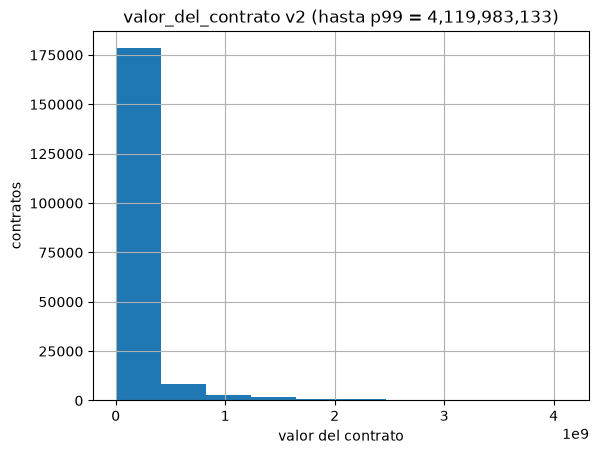

In [81]:
# Se va a graficar p99 para tener un gráfico no tan afectado por los outliers.
p99 = df['valor_del_contrato_v2'].quantile(0.99)
df.loc[df['valor_del_contrato_v2'] <= p99, 'valor_del_contrato_v2'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title(f'valor_del_contrato v2 (hasta p99 = {p99:,.0f})')
plt.show()


Conclusión: `valor_del_contrato` es de cola pesada. Se limpian **un outlier extremo** y **los ceros**.

- Un valor de contrato = 0 no tiene sentido en compraventa/suministros (188 filas, ~0.1%). Se anulan en `v2`, igual que el 12.86e15. Las filas se conservan para el resto de atributos.
- Tras esa limpieza, la mediana sigue en **~33.6 millones** y la media baja a **~351 millones**. El contrato típico es de mínima/menor cuantía; la media la empujan contratos grandes reales.
- p75 = 100 millones, p99 ≈ 4,117 millones, máximo v2 ≈ 2.85 billones. Sigue el sesgo (~200): muchos contratos chicos y unos pocos enormes.
- Para supervisión, el valor de firma sí es un atributo útil (magnitud del riesgo fiscal), pero hay que mirar **medianas/percentiles o umbrales** (p. ej. p95), no la media.


Atributo 2: `valor_pagado`

Mismo procedimiento descriptivo. **No** se filtran ceros ni se anula el máximo: el 0 es informativo (no se ha pagado) y el máximo (~594 mil millones) es coherente con el valor del contrato.


count         196391.00
mean       119491099.77
std       2444116099.87
min                0.00
1%                 0.00
5%                 0.00
25%                0.00
50%                0.00
75%         28120772.50
95%        312000000.00
99%       1714289389.80
99.9%    12397799847.74
max     594403394800.00
Name: valor_pagado, dtype: float64
Sesgo: 168.34564944454127
Kurtosis: 36616.255398901856
Ceros en valor_pagado: 107639
Proporción de ceros: 0.5480851973868456


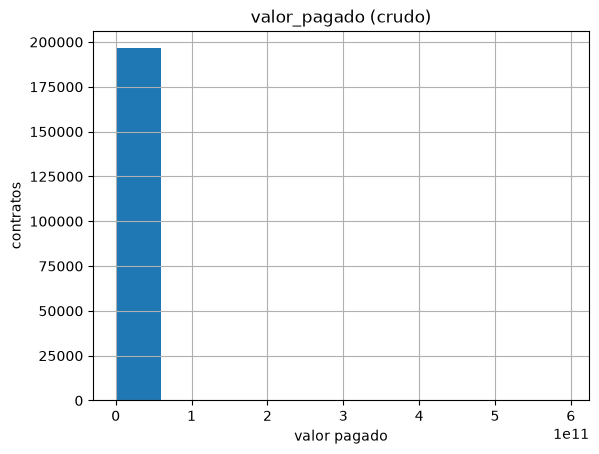

In [82]:
print(df['valor_pagado'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_pagado'].skew())
print("Kurtosis:", df['valor_pagado'].kurtosis())
print("Ceros en valor_pagado:", (df['valor_pagado'] == 0).sum())
print("Proporción de ceros:", (df['valor_pagado'] == 0).mean())

df['valor_pagado'].hist()
plt.xlabel('valor pagado')
plt.ylabel('contratos')
plt.title('valor_pagado (crudo)')
plt.show()


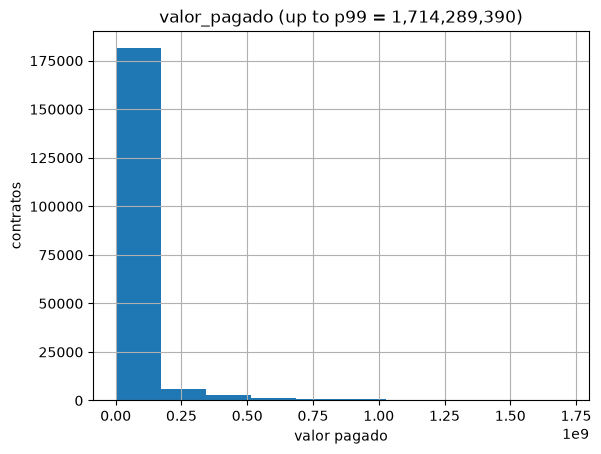

In [83]:
p99_pagado = df['valor_pagado'].quantile(0.99)
df.loc[df['valor_pagado'] <= p99_pagado, 'valor_pagado'].hist()
plt.xlabel('valor pagado')
plt.ylabel('contratos')
plt.title(f'valor_pagado (up to p99 = {p99_pagado:,.0f})')
plt.show()


Conclusión: `valor_pagado` también es de cola derecha (sesgo 168, kurtosis 36,616), pero los ceros **sí son el caso típico** y no se deben borrar.

- **107,639 contratos (54.8%)** tienen pagado = 0. Mediana 0, media ~119 millones. Si filtráramos ceros, tiraríamos justo la señal de subejecución del enunciado.
- A diferencia de `valor_del_contrato`, el máximo (594 mil millones) cuadra con el valor contratado de ese registro; no se trata como error ni se crea una `_v2`.
- El cruce útil más adelante es la **razón pagado / contratado** sobre contratos ya cerrados, no el histograma de pagos en crudo ni el subconjunto pagado > 0.


## 1.1.1.3. Desviación de cierre
Atributo: `estado_contrato`

Análisis univariado de variable **categórica**. Mostramos frecuencias y un gráfico de barras.


estado_contrato
terminado       54230
En ejecución    51441
Cerrado         46824
Modificado      34462
Aprobado         9211
Suspendido        153
cedido             43
Cancelado          26
Borrador            1
Name: count, dtype: int64

estado_contrato
terminado      0.28
En ejecución   0.26
Cerrado        0.24
Modificado     0.18
Aprobado       0.05
Suspendido     0.00
cedido         0.00
Cancelado      0.00
Borrador       0.00
Name: proportion, dtype: float64
Nulos: 0
Categorías: 9


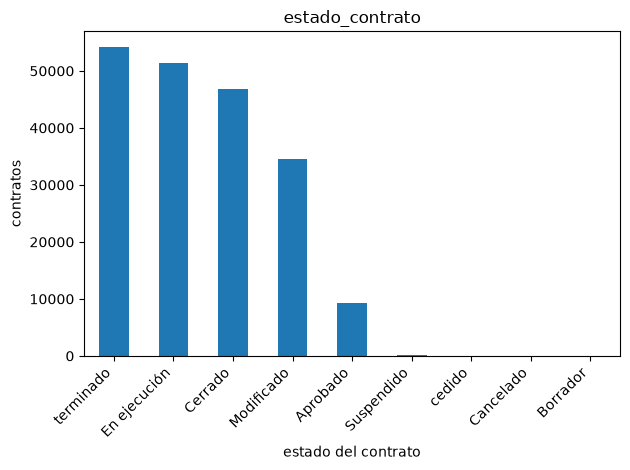

In [84]:
print(df['estado_contrato'].value_counts(dropna=False))
print()
print(df['estado_contrato'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['estado_contrato'].isna().sum())
print("Categorías:", df['estado_contrato'].nunique())

df['estado_contrato'].value_counts().plot(kind='bar')
plt.xlabel('estado del contrato')
plt.ylabel('contratos')
plt.title('estado_contrato')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Conclusión: `estado_contrato` tiene **9 categorías**, sin nulos. Cuatro estados concentran casi todo el dataset.

- `terminado` 27.6%, `En ejecución` 26.2%, `Cerrado` 23.8%, `Modificado` 17.6%. Juntos son ~95%.
- Casi la mitad **aún no está cerrada**: `En ejecución` + `Modificado` + `Aprobado` + `Suspendido` ≈ 48.5%. Esos contratos no sirven para medir subejecución (un pagado = 0 puede ser solo que todavía no pagan).
- Terminados/cerrados (`terminado` + `Cerrado`) son ~51.5%: ese es el universo razonable para desviación de cierre y de presupuesto.
- Calidad: etiquetas inconsistentes (`terminado` vs `Cerrado`, `cedido` en minúscula). `Borrador` (1) y `Cancelado` (26) son raros; el borrador no debería estar en un extracto de contratos firmados.
- No se crea una `_v2` numérica. Más adelante se filtrarán los estados abiertos para el análisis de outcomes.


## 1.1.2. sector

## 1.1.3. tipo_de_contrato

## 1.1.4 modalidad_de_contratacion

## 1.1.5. Departamento

# 2.1. 

Identificamos que hay unos contratos que aún se están ejecutando, por lo que es necesario que sean filtrado del análisis. Serán filtrados los contratos con `estado_contrato` entre (`En ejecución`, `Modificado`, `Aprobado`, `Suspendido`)